# Notebook 2 — K-Anonymity
Sensitive attribute: `fitness_level` only. Quasi-identifiers: `age`, `region`, `activity`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../data', exist_ok=True)
os.makedirs('../results', exist_ok=True)

df = pd.read_csv('../data/raw_fitness_data.csv')
assert 'fitness_level' in df.columns, 'Run Notebook 1 first.'

print(f'✅ Dataset loaded — shape: {df.shape}')
print(f'   Columns: {list(df.columns)}')
print('\nfitness_level distribution (sensitive attribute):')
print(df['fitness_level'].value_counts())
print(df.head())

✅ Dataset loaded — shape: (7000, 11)
   Columns: ['age', 'region', 'activity', 'heart_rate', 'steps', 'calories', 'step_range', 'calories_range', 'sleep_hours', 'weight_kg', 'fitness_level']

fitness_level distribution (sensitive attribute):
fitness_level
moderately_fit    4039
unfit             1488
fit               1473
Name: count, dtype: int64
   age region activity  heart_rate  steps  calories step_range calories_range  \
0   22   East      Gym          85  10170       433     8k-11k        400-550   
1   20  South  Running         105  11890       545    11k-14k        400-550   
2   50  North      Gym          62   6461       270      5k-8k        250-400   
3   29  North      Gym          77  12858       687    11k-14k        550-700   
4   31  North  Walking          68  11024       486    11k-14k        400-550   

   sleep_hours  weight_kg   fitness_level  
0         5.81       76.0  moderately_fit  
1         5.94       79.1  moderately_fit  
2         7.19       71.1     

In [2]:
quasi_identifiers  = ['age', 'region', 'activity']
sensitive_attribute = 'fitness_level'  # ONLY sensitive attribute
k = 5

group_sizes_before = df.groupby(quasi_identifiers).size()
violations_before  = (group_sizes_before < k).sum()

print('BEFORE K-ANONYMITY:')
print(f'  Total groups:     {len(group_sizes_before)}')
print(f'  Violating groups: {violations_before}')
print(f'  Violation rate:   {100*violations_before/len(group_sizes_before):.1f}%')
print('\nGroup size stats:')
print(group_sizes_before.describe())

BEFORE K-ANONYMITY:
  Total groups:     1001
  Violating groups: 499
  Violation rate:   49.9%

Group size stats:
count    1001.000000
mean        6.993007
std         6.915559
min         1.000000
25%         2.000000
50%         5.000000
75%         9.000000
max        48.000000
dtype: float64


In [3]:
# --- Step 1: Generalise age to 5-year bins ---
df_k = df.copy()

bins   = list(range(15, 80, 5))
labels = [f'{i}-{i+4}' for i in bins[:-1]]

df_k['age'] = pd.cut(df_k['age'], bins=bins, labels=labels, include_lowest=True)

gs = df_k.groupby(quasi_identifiers).size()
print('After age generalisation:')
print(f'  Violating groups: {(gs < k).sum()} / {len(gs)}')

After age generalisation:
  Violating groups: 24 / 235


In [4]:
# --- Step 2: Generalise region ---
region_map = {'North': 'North', 'South': 'South', 'East': 'other', 'West': 'other'}
df_k['region'] = df_k['region'].map(region_map)

gs = df_k.groupby(quasi_identifiers).size()
print('After region generalisation:')
print(f'  Violating groups: {(gs < k).sum()} / {len(gs)}')

After region generalisation:
  Violating groups: 13 / 179


In [5]:
# --- Step 3: Generalise activity ---
act_map = {'Gym': 'Gym/Sports', 'Sports': 'Gym/Sports', 'Walking': 'Walking', 'Cycling': 'Cycling', 'Running': 'Running'}
df_k['activity'] = df_k['activity'].replace(act_map)

final_group_sizes = df_k.groupby(quasi_identifiers).size()
final_violations  = (final_group_sizes < k).sum()

print('After activity generalisation:')
print(f'  Total groups:     {len(final_group_sizes)}')
print(f'  Min group size:   {final_group_sizes.min()}')
print(f'  Violating groups: {final_violations}')

if final_violations == 0:
    print(f'\n✅ K-ANONYMITY (k={k}) ACHIEVED!')
else:
    print(f'\n⚠️ {final_violations} violations remain')

After activity generalisation:
  Total groups:     143
  Min group size:   1
  Violating groups: 7

⚠️ 7 violations remain


In [6]:
# Diversity check (informational) — how many fitness_level values per group?
fl_diversity = df_k.groupby(quasi_identifiers)['fitness_level'].nunique()
print('fitness_level diversity per equivalence class (k-anonymised):')
print(fl_diversity.value_counts().sort_index())
print(f'\nGroups lacking all 3 classes: {(fl_diversity < 3).sum()}')

fitness_level diversity per equivalence class (k-anonymised):
fitness_level
1     4
2    64
3    75
Name: count, dtype: int64

Groups lacking all 3 classes: 68


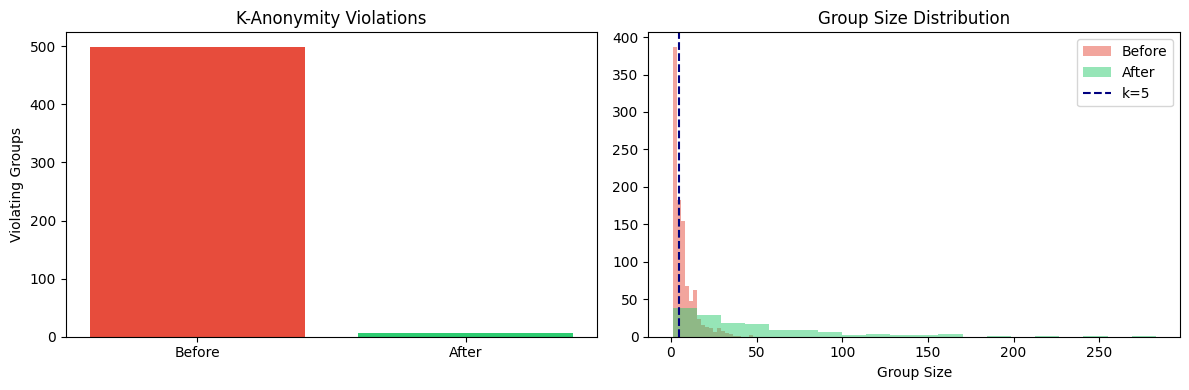

✅ Saved: ../results/k_anonymity_analysis.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Before', 'After'], [violations_before, final_violations], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('K-Anonymity Violations')
axes[0].set_ylabel('Violating Groups')

axes[1].hist(group_sizes_before, bins=20, alpha=0.5, label='Before', color='#e74c3c')
axes[1].hist(final_group_sizes,  bins=20, alpha=0.5, label='After',  color='#2ecc71')
axes[1].axvline(x=k, color='navy', linestyle='--', label=f'k={k}')
axes[1].set_title('Group Size Distribution')
axes[1].set_xlabel('Group Size')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/k_anonymity_analysis.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Saved: ../results/k_anonymity_analysis.png')

In [8]:
import json

df_k.to_csv('../data/k_anonymized.csv', index=False)
print('✅ Saved: ../data/k_anonymized.csv')

k_metrics_out = {
    'k_value': k,
    'violations': int(final_violations),
    'violation_rate': float(final_violations / len(final_group_sizes)),
    'records_original': len(df),
    'records_after': len(df_k),
    'data_loss_percent': float((len(df) - len(df_k)) / len(df) * 100),
    'sensitive_attribute': 'fitness_level',
    'fitness_level_l_violations': int((fl_diversity < 3).sum())
}
with open('../results/k_anonymity_metrics.json', 'w') as f:
    json.dump({'k_anonymity_metrics': k_metrics_out}, f, indent=2)

print('\nSummary:')
for k_key, v in k_metrics_out.items():
    print(f'  {k_key}: {v}')

✅ Saved: ../data/k_anonymized.csv

Summary:
  k_value: 5
  violations: 7
  violation_rate: 0.04895104895104895
  records_original: 7000
  records_after: 7000
  data_loss_percent: 0.0
  sensitive_attribute: fitness_level
  fitness_level_l_violations: 68
